# analysis: restricted-policy value gap

This notebook reads every MDP seed whose status is `accepted` in `results.json`. Re-running the experiment with additional seeds and then executing this notebook automatically updates the statistics and figures.

The plotted quantity is temporarily denoted by `delta W` and is computed from the stored value `normal_minus_restricted_value`.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

candidate_root = Path.cwd()
if not (candidate_root / 'results.json').is_file():
    candidate_root = Path('experiments/gap_lower_upper_scheme_1').resolve()
ROOT = candidate_root
PLOTS = ROOT / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
})

def save_figure(fig, stem):
    fig.savefig(PLOTS / f'{stem}.png', bbox_inches='tight')
    fig.savefig(PLOTS / f'{stem}.pdf', bbox_inches='tight')

In [2]:
payload = json.loads((ROOT / 'results.json').read_text(encoding='utf-8'))
experiment = payload['experiment']
accepted_seeds = [
    int(item['mdp_seed'])
    for item in payload['seed_statuses']
    if item['status'] == 'accepted'
]
epsilons = np.round(np.asarray(experiment['epsilons'], dtype=float), 10)
accepted_set = set(accepted_seeds)
records = [
    item for item in payload['points']
    if item.get('status') == 'ok' and int(item['mdp_seed']) in accepted_set
]
by_key = {
    (int(item['mdp_seed']), int(item['epsilon_index'])): item
    for item in records
}
expected_points = len(accepted_seeds) * len(epsilons)
if len(by_key) != expected_points:
    raise RuntimeError(f'accepted grid has {len(by_key)} points; expected {expected_points}')

delta_w = np.asarray([
    [
        float(by_key[(seed, epsilon_index)]['normal_minus_restricted_value'])
        for epsilon_index in range(len(epsilons))
    ]
    for seed in accepted_seeds
])

print(f'Accepted seeds: {len(accepted_seeds)}')
print(f'Complete runs: {delta_w.size}')

Accepted seeds: 30
Complete runs: 300


## Delta W and solver statistics

The conditional mean reports the average magnitude among seeds for which `delta W > 0`. Solver precision is reported separately and is not added to either figure.

In [3]:
statistics_rows = []
for epsilon_index, epsilon in enumerate(epsilons):
    values = delta_w[:, epsilon_index]
    positive = values[values > 0.0]
    statistics_rows.append({
        'epsilon': epsilon,
        'n_seeds': values.size,
        'mean_delta_w': np.mean(values),
        'std_delta_w': np.std(values, ddof=1),
        'median_delta_w': np.median(values),
        'min_delta_w': np.min(values),
        'max_delta_w': np.max(values),
        'positive_count': positive.size,
        'positive_fraction': positive.size / values.size,
        'positive_percent': 100.0 * positive.size / values.size,
        'mean_positive_delta_w': np.nan if positive.size == 0 else np.mean(positive),
        'std_positive_delta_w': (
            np.nan if positive.size < 2 else np.std(positive, ddof=1)
        ),
    })

delta_w_statistics = pd.DataFrame(statistics_rows)
delta_w_statistics.to_csv(ROOT / 'delta_w_statistics.csv', index=False)
display(delta_w_statistics.style.format({
    'epsilon': '{:.2f}',
    'mean_delta_w': '{:.6f}',
    'std_delta_w': '{:.6f}',
    'median_delta_w': '{:.6f}',
    'min_delta_w': '{:.6f}',
    'max_delta_w': '{:.6f}',
    'positive_fraction': '{:.3f}',
    'positive_percent': '{:.1f}',
    'mean_positive_delta_w': '{:.6f}',
    'std_positive_delta_w': '{:.6f}',
}))

,epsilon,n_seeds,mean_delta_w,std_delta_w,median_delta_w,min_delta_w,max_delta_w,positive_count,positive_fraction,positive_percent,mean_positive_delta_w,std_positive_delta_w
0,0.01,30,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000,0.0,nan,nan
1,0.02,30,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000,0.0,nan,nan
2,0.03,30,0.000340,0.001863,0.000000,0.000000,0.010202,1,0.033,3.3,0.010202,nan
3,0.04,30,0.002666,0.008813,0.000000,0.000000,0.036800,3,0.100,10.0,0.026662,0.012906
4,0.05,30,0.002874,0.009271,0.000000,0.000000,0.038148,4,0.133,13.3,0.021556,0.017144
5,0.06,30,0.003505,0.010150,0.000000,0.000000,0.039470,5,0.167,16.7,0.021030,0.016916
6,0.07,30,0.005503,0.012534,0.000000,0.000000,0.040767,7,0.233,23.3,0.023586,0.016178
7,0.08,30,0.008082,0.018648,0.000000,0.000000,0.079479,6,0.200,20.0,0.040412,0.021195
8,0.09,30,0.007426,0.019101,0.000000,0.000000,0.084542,7,0.233,23.3,0.031826,0.029283
9,0.10,30,0.009822,0.021998,0.000000,0.000000,0.089532,6,0.200,20.0,0.049110,0.022164


In [4]:
positive_seed_mask = np.any(delta_w > 0.0, axis=1)
overall_statistics = pd.Series({
    'accepted_seeds': delta_w.shape[0],
    'complete_runs': delta_w.size,
    'seeds_positive_at_any_epsilon': int(np.count_nonzero(positive_seed_mask)),
    'fraction_positive_at_any_epsilon': float(np.mean(positive_seed_mask)),
    'global_mean_delta_w': float(np.mean(delta_w)),
    'global_std_delta_w': float(np.std(delta_w, ddof=1)),
    'global_max_delta_w': float(np.max(delta_w)),
})
display(overall_statistics.to_frame('value'))

policy_gap_by_run = pd.DataFrame([
    {
        'mdp_seed': seed,
        'epsilon': epsilons[epsilon_index],
        'delta_w': item['normal_minus_restricted_value'],
        'delta_w_lower': item['normal_minus_restricted_lower'],
        'delta_w_upper': item['normal_minus_restricted_upper'],
        'unrestricted_policy_value': item['normal_policy_value'],
        'restricted_policy_value': item['restricted_policy_value'],
        'violation_count': item['violation_count'],
    }
    for seed in accepted_seeds
    for epsilon_index in range(len(epsilons))
    for item in [by_key[(seed, epsilon_index)]]
])
policy_gap_by_run.to_csv(ROOT / 'policy_gap_by_run.csv', index=False)

target_precision = float(experiment['solver']['precision'])
acceptance_threshold = float(experiment['solver_gap_acceptance_threshold'])
solver_gap_by_run = pd.DataFrame([
    {
        'mdp_seed': seed,
        'epsilon': epsilons[epsilon_index],
        'sarsop_gap': item['sarsop_gap'],
        'solver_stop_reason': item['solver_stop_reason'],
        'solver_elapsed_seconds': item['solver_elapsed_seconds'],
        'target_precision': target_precision,
        'acceptance_threshold': acceptance_threshold,
    }
    for seed in accepted_seeds
    for epsilon_index in range(len(epsilons))
    for item in [by_key[(seed, epsilon_index)]]
])
solver_gap_by_run.to_csv(ROOT / 'solver_gap_by_run.csv', index=False)

solver_statistics_rows = []
for epsilon in epsilons:
    subset = solver_gap_by_run[solver_gap_by_run['epsilon'] == epsilon]
    gaps = subset['sarsop_gap'].to_numpy(dtype=float)
    maximum_row = subset.loc[subset['sarsop_gap'].idxmax()]
    solver_statistics_rows.append({
        'epsilon': epsilon,
        'n_runs': gaps.size,
        'mean_sarsop_gap': np.mean(gaps),
        'median_sarsop_gap': np.median(gaps),
        'p90_sarsop_gap': np.quantile(gaps, 0.90),
        'max_sarsop_gap': np.max(gaps),
        'seed_with_max_sarsop_gap': int(maximum_row['mdp_seed']),
        'runs_at_target_precision': np.count_nonzero(gaps <= target_precision),
        'runs_within_acceptance_threshold': np.count_nonzero(
            gaps <= acceptance_threshold
        ),
        'precision_stop_count': np.count_nonzero(
            subset['solver_stop_reason'] == 'precision'
        ),
        'max_time_stop_count': np.count_nonzero(
            subset['solver_stop_reason'] == 'max_time'
        ),
    })

solver_gap_statistics = pd.DataFrame(solver_statistics_rows)
solver_gap_statistics.to_csv(ROOT / 'solver_gap_summary.csv', index=False)
all_solver_gaps = solver_gap_by_run['sarsop_gap'].to_numpy(dtype=float)
stop_reason_counts = {
    str(reason): int(count)
    for reason, count in solver_gap_by_run['solver_stop_reason'].value_counts().items()
}
solver_gap_summary = {
    'accepted_seed_count': len(accepted_seeds),
    'accepted_mdp_seeds': accepted_seeds,
    'run_count': int(all_solver_gaps.size),
    'target_precision': target_precision,
    'acceptance_threshold': acceptance_threshold,
    'mean_sarsop_gap': float(np.mean(all_solver_gaps)),
    'median_sarsop_gap': float(np.median(all_solver_gaps)),
    'p90_sarsop_gap': float(np.quantile(all_solver_gaps, 0.90)),
    'p95_sarsop_gap': float(np.quantile(all_solver_gaps, 0.95)),
    'max_sarsop_gap': float(np.max(all_solver_gaps)),
    'runs_at_target_precision': int(np.count_nonzero(
        all_solver_gaps <= target_precision
    )),
    'fraction_at_target_precision': float(np.mean(
        all_solver_gaps <= target_precision
    )),
    'runs_within_acceptance_threshold': int(np.count_nonzero(
        all_solver_gaps <= acceptance_threshold
    )),
    'fraction_within_acceptance_threshold': float(np.mean(
        all_solver_gaps <= acceptance_threshold
    )),
    'solver_stop_reason_counts': stop_reason_counts,
}
(ROOT / 'solver_gap_summary.json').write_text(
    json.dumps(solver_gap_summary, indent=2, sort_keys=True),
    encoding='utf-8',
)
display(pd.Series(solver_gap_summary).drop('accepted_mdp_seeds').to_frame('value'))
display(solver_gap_statistics.style.format({
    'epsilon': '{:.2f}',
    'mean_sarsop_gap': '{:.6f}',
    'median_sarsop_gap': '{:.6f}',
    'p90_sarsop_gap': '{:.6f}',
    'max_sarsop_gap': '{:.6f}',
}))

,value
accepted_seeds,30.000000
complete_runs,300.000000
seeds_positive_at_any_epsilon,7.000000
fraction_positive_at_any_epsilon,0.233333
global_mean_delta_w,0.004022
global_std_delta_w,0.012994
global_max_delta_w,0.089532


,value
accepted_seed_count,30
run_count,300
target_precision,0.01
acceptance_threshold,0.5
mean_sarsop_gap,0.019957
median_sarsop_gap,0.011074
p90_sarsop_gap,0.043981
p95_sarsop_gap,0.054235
max_sarsop_gap,0.081821
runs_at_target_precision,38


,epsilon,n_runs,mean_sarsop_gap,median_sarsop_gap,p90_sarsop_gap,max_sarsop_gap,seed_with_max_sarsop_gap,runs_at_target_precision,runs_within_acceptance_threshold,precision_stop_count,max_time_stop_count
0,0.01,30,0.011906,0.010981,0.020457,0.024698,826965060,4,30,23,7
1,0.02,30,0.012560,0.010926,0.020931,0.030547,1267533685,6,30,21,9
2,0.03,30,0.014867,0.011043,0.027136,0.037196,1267533685,2,30,19,11
3,0.04,30,0.015672,0.011036,0.028255,0.039017,1267533685,3,30,18,12
4,0.05,30,0.020219,0.011043,0.037475,0.057523,978475358,6,30,16,14
5,0.06,30,0.024213,0.014403,0.047205,0.079546,978475358,5,30,14,16
6,0.07,30,0.025491,0.018718,0.053338,0.072964,978475358,2,30,13,17
7,0.08,30,0.023002,0.016250,0.048725,0.064563,978475358,4,30,15,15
8,0.09,30,0.025203,0.018396,0.054834,0.068107,978475358,4,30,15,15
9,0.10,30,0.026439,0.018366,0.056858,0.081821,978475358,2,30,14,16


## Individual trajectories and mean

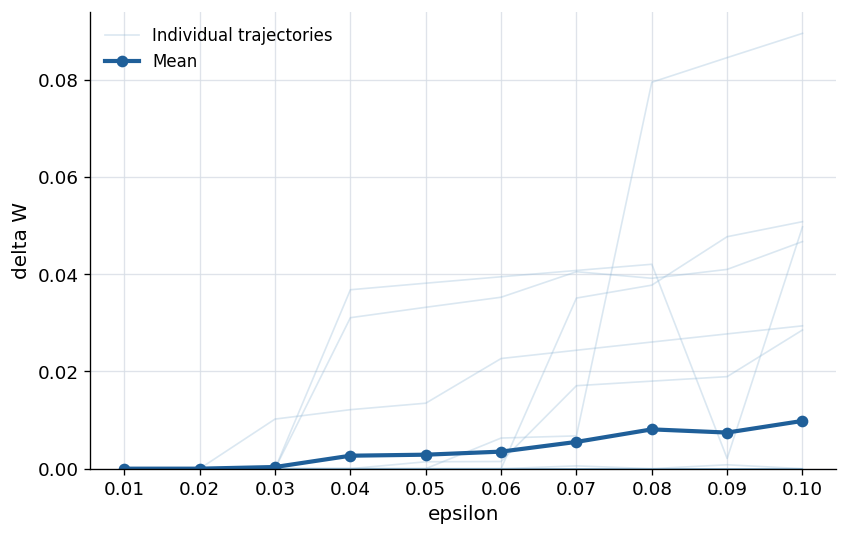

In [5]:
trajectory_color = '#8fb7d5'
mean_color = '#1f5f99'

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for row_index, row in enumerate(delta_w):
    ax.plot(
        epsilons,
        row,
        color=trajectory_color,
        alpha=0.32,
        linewidth=1.0,
        label='Individual trajectories' if row_index == 0 else None,
    )
ax.plot(
    epsilons,
    np.mean(delta_w, axis=0),
    color=mean_color,
    marker='o',
    linewidth=2.5,
    label='Mean',
)
ax.set_xlabel('epsilon')
ax.set_ylabel('delta W')
ax.set_xticks(epsilons)
ax.set_xticklabels([f'{value:.2f}' for value in epsilons])
ax.set_ylim(bottom=0.0)
ax.grid(True, color='#d7dde5', linewidth=0.8, alpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, 'delta_w_mean_trajectories')
plt.show()

## Fraction of seeds with a positive gap

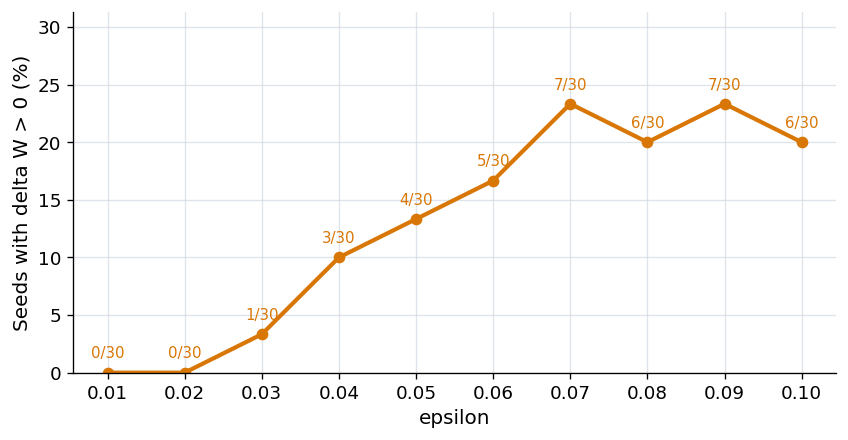

In [6]:
positive_counts = np.count_nonzero(delta_w > 0.0, axis=0)
positive_percent = 100.0 * positive_counts / delta_w.shape[0]

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(
    epsilons,
    positive_percent,
    color='#d97706',
    marker='o',
    linewidth=2.5,
)
for epsilon, percent, count in zip(epsilons, positive_percent, positive_counts):
    ax.annotate(
        f'{count}/{delta_w.shape[0]}',
        (epsilon, percent),
        xytext=(0, 7),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#d97706',
    )
ax.set_xlabel('epsilon')
ax.set_ylabel('Seeds with delta W > 0 (%)')
ax.set_xticks(epsilons)
ax.set_xticklabels([f'{value:.2f}' for value in epsilons])
ax.set_ylim(0.0, max(10.0, float(np.max(positive_percent)) + 8.0))
ax.grid(True, color='#d7dde5', linewidth=0.8, alpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_figure(fig, 'positive_delta_w_share')
plt.show()